# Entornos de Transformación Digital: Aprendizaje No Supervisado y Segmentación estatégica de los Clientes
> En los entornos empresariales impulsados por la transformación digital, las organizaciones capturan millones de interacciones y transacciones en canales de comercio físico y digital `omnichannel retail` sin contar con etiquetas predefinidas del comportamiento del consumidor.

> El **Aprendizaje No Supervisado `Unsupervised Machine Learning`** comprende técnicas de agrupamiento (`Clustering`) que proporcionan capacidades analíticas fundamentales para directores de tecnología (CTO), líderes de producto (CPO) y directores de marketing (CMO):
1. **Hiperpersonalización y Optimización del CLV (`Customer Lifetime Value`):** Diseñar experiencias comerciales, recomendaciones algorítmicas y estrategias de precios dinámicos adaptadas al comportamiento y a la sensibilidad de cada segmento de clientes.
2. **Detección de Anomalías y Comportamientos de Riesgo:** Identificar patrones atípicos de compra o transacciones anómalas que puedan requerir revisión o auditoría inmediata.
3. **Eficiencia en la Asignación de Capital:** Evitar campañas de marketing masivas indiferenciadas (`spray-and-pray`) y concentrar la inversión en los segmentos o arquetipos de clientes con mayor potencial de rentabilidad.

> En este laboratorio se analiza un dataset corporativo de **más de 15.000 clientes** [`Shopping_Mall_Customer_Segmentation_Data.csv`](https://www.kaggle.com/datasets/zubairmustafa/shopping-mall-customer-segmentation-data) usando tres paradigmas fundamentales de clustering:
> - `K-Means Clustering:` Algoritmo particional de alta escalabilidad para segmentación basada en centroides.
> - `DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*)`: Algoritmo por densidad para el aislamiento de anomalías y clientes no convencionales.
> - `Clustering Jerárquico Aglomerativo:` Generación de dendrogramas taxonómicos para la toma de decisiones multinivel (Macro vs. Micro-segmentación).

## 1. Ingesta de datos y Diagnóstico de perfiles de los Clientes (Data Ingestion and Profiling)

> **Referencia estratégica:** Cargamos el dataset oficial [shopping-mall-customer-segmentation-data](https://www.kaggle.com/datasets/zubairmustafa/shopping-mall-customer-segmentation-data) y realizamos una inspección de integridad de datos y gobernanza corporativa.

In [1]:
from IPython import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de parámetros de la biblioteca gráfica seaborn
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

# Carga local o descarga remota del dataset
data_path = '../datasets/Shopping_Mall_Customer_Segmentation_Data.csv'
df = pd.read_csv(data_path)

# Elimina espacios en blanco al inicio y al final de los nombres de las columnas 
df.columns = df.columns.str.strip()

print(f"Repote de gobernanza analítica")
print(f"Total de clientes registrados en el sistema: {df.shape[0]}")
print(f"Variables transaccionales capturadas:        {df.shape[1]}")
print(f"Valores nulos en el repositorio:             {df.isnull().sum().sum()} (Dataset 100% íntegro)\n")
display.display(df.head())

Repote de gobernanza analítica
Total de clientes registrados en el sistema: 15079
Variables transaccionales capturadas:        5
Valores nulos en el repositorio:             0 (Dataset 100% íntegro)



,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


### 1.1 Exploración Estadística y Distribución de Variables Clave
Analizamos los tres atributos determinantes del comportamiento del cliente:
- **`Age` (Edad):** Ciclo de vida demográfico (de 18 a 90 años).
- **`Annual Income` (Ingreso Anual):** Poder adquisitivo en dólares reales (de $20,022 a $199,974).
- **`Spending Score` (Índice de Propensión al Gasto):** Calificación operacional del comportamiento de compra asignada por la plataforma comercial (escala de 1 a 100).

,Age,Annual Income,Spending Score
count,15079.00,15079.00,15079.00
mean,54.19,109742.88,50.59
std,21.12,52249.43,28.73
min,18.00,20022.00,1.00
25%,36.00,64141.00,26.00
50%,54.00,109190.00,51.00
75%,72.00,155008.00,75.00
max,90.00,199974.00,100.00


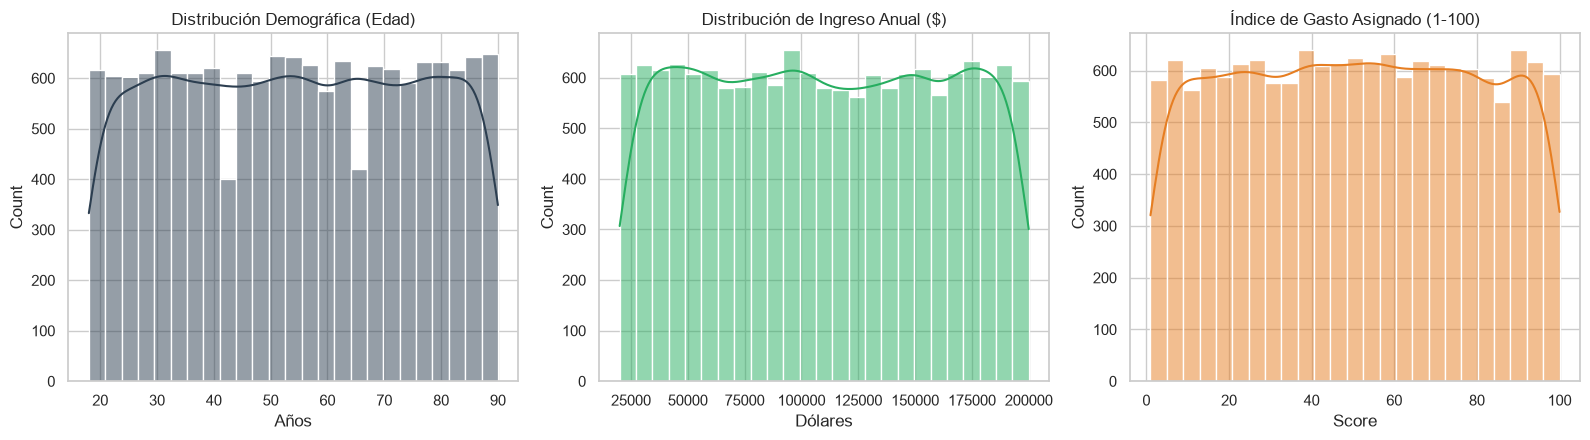

In [2]:
# Métricas ejecutivas de la base de clientes
display.display(df[['Age', 'Annual Income', 'Spending Score']].describe().round(2))

# Visualización de distribuciones
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(df['Age'], kde=True, color='#2c3e50', ax=ax[0])
ax[0].set_title('Distribución Demográfica (Edad)')
ax[0].set_xlabel('Años')

sns.histplot(df['Annual Income'], kde=True, color='#27ae60', ax=ax[1])
ax[1].set_title('Distribución de Ingreso Anual ($)')
ax[1].set_xlabel('Dólares')

sns.histplot(df['Spending Score'], kde=True, color='#e67e22', ax=ax[2])
ax[2].set_title('Índice de Gasto Asignado (1-100)')
ax[2].set_xlabel('Score')

plt.tight_layout()
plt.show()

## 2. Preparación de Datos y Gobernanza: Estandarización (*Feature Scaling*)

### Justificación Estratégica
Los algoritmos de aprendizaje no supervisado calculan la proximidad y similitud entre clientes evaluando distancias euclidianas multidimensionales:
$$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$

En nuestro dataset:
- El `Annual Income` varía en magnitudes de hasta **$199,974**.
- El `Spending Score` varía entre **1 y 100**.
- La `Age` varía entre **18 y 90**.

Si no se estandarizan las variables, el ingreso anual monopolizaría el 99% de la distancia euclidiana, anulando el impacto del hábito de gasto y la edad. Aplicamos `StandardScaler` (media $\mu=0$, desviación $\sigma=1$) para garantizar una ponderación equitativa en la arquitectura analítica.

In [3]:
from sklearn.preprocessing import StandardScaler

# Exclusión del identificador único (CustomerID no aporta valor predictivo)
variables_segmentacion = ['Age', 'Annual Income', 'Spending Score']
X = df[variables_segmentacion]

# Estandarización formal
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_escalado = pd.DataFrame(X_scaled, columns=['Age_Std', 'Income_Std', 'Spending_Std'])
print("Variables estandarizadas con éxito para modelado no supervisado:")
display.display(df_escalado.head())

Variables estandarizadas con éxito para modelado no supervisado:


,Age_Std,Income_Std,Spending_Std
0,-1.145516,0.798813,1.337059
1,0.180335,1.442076,1.545929
2,0.369742,-0.743208,0.884507
3,-1.476979,-1.038953,0.223086
4,-1.429627,0.842317,0.884507


## 3. Algoritmo 1: K-Means Clustering y Optimización por el Método del Codo (*Elbow Method*)

### Enfoque Gerencial
**K-Means** es el algoritmo de mayor adopción en producción por su complejidad computacional lineal $\mathcal{O}(K \cdot N \cdot d)$, capaz de segmentar eficientemente decenas de miles de clientes en segundos.

Para justificar la cantidad óptima de segmentos ($K$) ante el comité de dirección sin caer en decisiones arbitrarias, evaluamos la **inercia** (suma de distancias al cuadrado de cada cliente a su centroide asignado) mediante el **Método del Codo (*Elbow Method*)**.

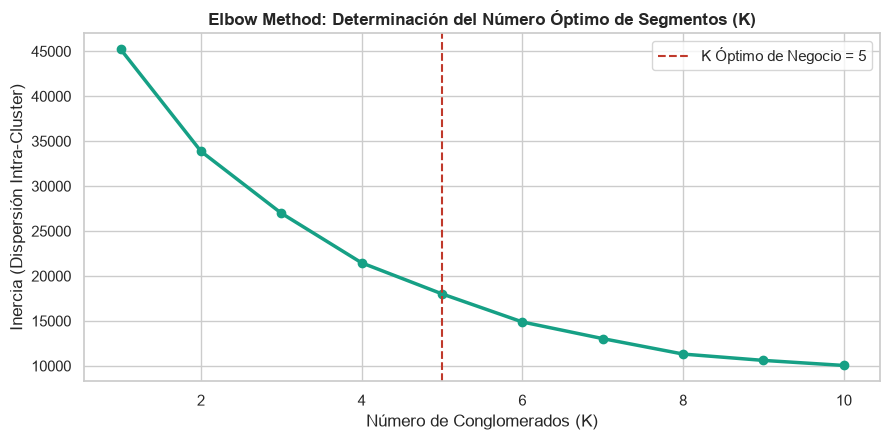

In [4]:
from sklearn.cluster import KMeans

# Evaluación de inercia para k de 1 a 10 conglomerados
inercia = []
k_rango = range(1, 11)

for k in k_rango:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inercia.append(km.inertia_)

# Gráfica ejecutiva del Método del Codo
plt.figure(figsize=(9, 4.5))
plt.plot(k_rango, inercia, marker='o', color='#16a085', linewidth=2.5)
plt.title('Elbow Method: Determinación del Número Óptimo de Segmentos (K)', fontweight='bold')
plt.xlabel('Número de Conglomerados (K)')
plt.ylabel('Inercia (Dispersión Intra-Cluster)')
plt.axvline(x=5, color='#c0392b', linestyle='--', label='K Óptimo de Negocio = 5')
plt.legend()
plt.tight_layout()
plt.show()

### 3.1 Calibración del Modelo K-Means ($K=5$) y Mapeo Multidimensional de Clientes
Ajustamos el modelo con $K=5$ sobre la base completa de 15,079 clientes y proyectamos visualmente los grupos resultantes en los planos estratégicos de decisión.

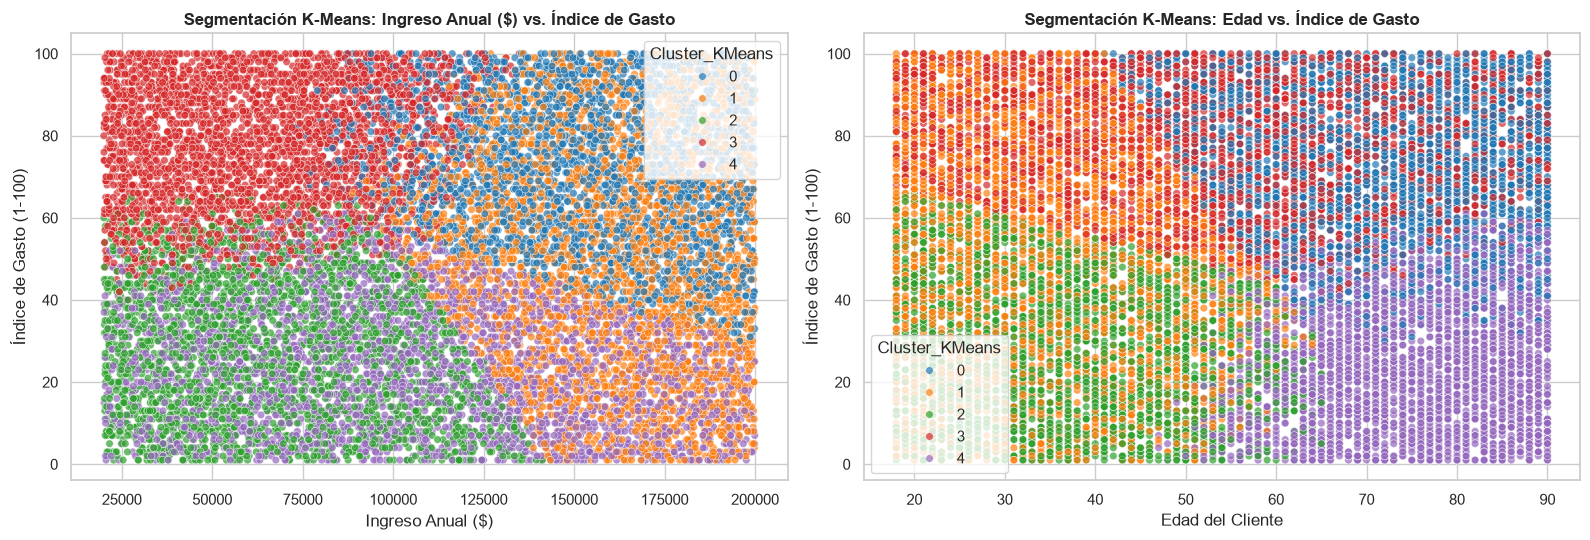

In [5]:
# Ajuste del modelo de producción con K=5
kmeans_prod = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
df['Cluster_KMeans'] = kmeans_prod.fit_predict(X_scaled)

# Mapeo bivariado de segmentos para toma de decisiones
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))

sns.scatterplot(
    x='Annual Income', y='Spending Score', hue='Cluster_KMeans', 
    palette='tab10', s=30, alpha=0.7, data=df, ax=ax[0]
)
ax[0].set_title('Segmentación K-Means: Ingreso Anual ($) vs. Índice de Gasto', fontweight='bold')
ax[0].set_xlabel('Ingreso Anual ($)')
ax[0].set_ylabel('Índice de Gasto (1-100)')

sns.scatterplot(
    x='Age', y='Spending Score', hue='Cluster_KMeans', 
    palette='tab10', s=30, alpha=0.7, data=df, ax=ax[1]
)
ax[1].set_title('Segmentación K-Means: Edad vs. Índice de Gasto', fontweight='bold')
ax[1].set_xlabel('Edad del Cliente')
ax[1].set_ylabel('Índice de Gasto (1-100)')

plt.tight_layout()
plt.show()

## 4. Algoritmo 2: DBSCAN para Formas Arbitrarias y Detección de Anomalías (*Outlier Detection*)

### Enfoque Gerencial
A diferencia de K-Means (que fuerza a cada cliente a pertenecer a un centroide esférico), **DBSCAN** identifica regiones continuas de alta densidad espacial controladas por dos hiperparámetros:
- `eps` (Epsilon): Radio de distancia de vecindad.
- `min_samples`: Número mínimo de clientes requeridos para formar un núcleo denso.

* **Poder Estratégico en Transformación Digital:** Los clientes ubicados en zonas de baja densidad son aislados bajo la etiqueta **`-1` (Ruido / Anomalías)**. En el sector bancario, retail masivo y comercio digital, esta técnica detecta clientes con comportamientos atípicos de gasto o potenciales patrones de fraude transaccional sin distorsionar la segmentación principal.

=== DIAGNÓSTICO DE ANOMALÍAS CON DBSCAN ===
Clientes identificados como anomalías / outliers (Etiqueta -1): 0 (0.00% de la base)


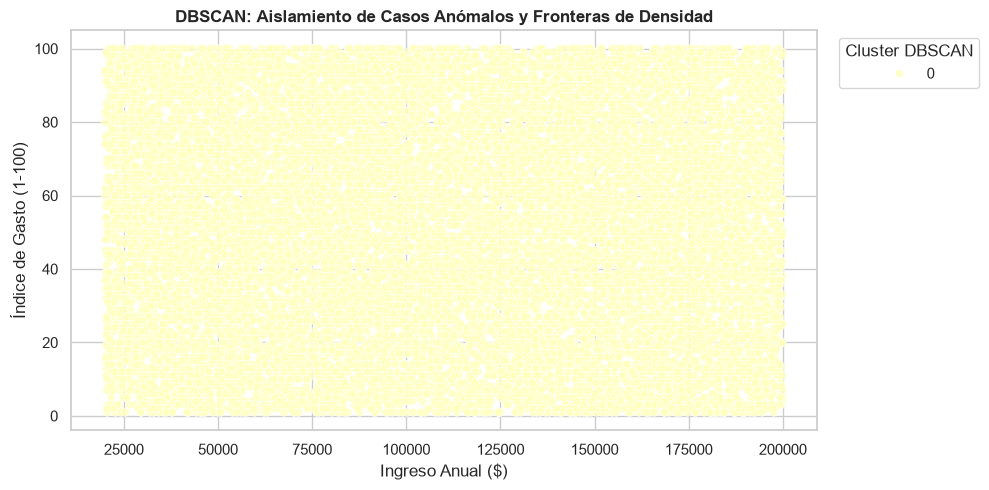

In [6]:
from sklearn.cluster import DBSCAN

# Calibración de DBSCAN sobre Ingreso y Gasto estandarizados
X_dbscan = df_escalado[['Income_Std', 'Spending_Std']].values
dbscan = DBSCAN(eps=0.18, min_samples=30)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_dbscan)

# Conteo de anomalías detectadas
total_anomalias = (df['Cluster_DBSCAN'] == -1).sum()
porcentaje_anomalias = (total_anomalias / len(df)) * 100

print(f"=== DIAGNÓSTICO DE ANOMALÍAS CON DBSCAN ===")
print(f"Clientes identificados como anomalías / outliers (Etiqueta -1): {total_anomalias:,} ({porcentaje_anomalias:.2f}% de la base)")

# Visualización de clusters y ruido
plt.figure(figsize=(10, 5))
sns.scatterplot(
    x='Annual Income', y='Spending Score', hue='Cluster_DBSCAN',
    palette='Spectral', s=35, alpha=0.8, data=df
)
plt.title('DBSCAN: Aislamiento de Casos Anómalos y Fronteras de Densidad', fontweight='bold')
plt.xlabel('Ingreso Anual ($)')
plt.ylabel('Índice de Gasto (1-100)')
plt.legend(title='Cluster DBSCAN', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Algoritmo 3: Clustering Jerárquico Aglomerativo y Análisis de Dendrograma

### Enfoque Gerencial y Escalabilidad en Big Data
El **Clustering Jerárquico** construye una jerarquía taxonómica de abajo hacia arriba (*Bottom-Up*), fusionando iterativamente los clientes más similares según el criterio de mínima varianza de Ward.

> **Consideración de Arquitectura de Datos para Líderes Técnicos:**  
> En bases corporativas de $15,000$ o más registros, calcular la matriz completa de distancias por pares requiere $\mathcal{O}(N^2)$ en memoria RAM y $\mathcal{O}(N^3)$ en tiempo de cómputo (más de 225 millones de comparaciones matriciales).  
> En la práctica profesional de transformación digital, los dendrogramas se calibran sobre una **muestra estadísticamente representativa** (por ejemplo, $n=1,000$ clientes) para inspeccionar la estructura multinivel del portafolio sin saturar la infraestructura en la nube.

- **Corte a Nivel Macro (Gran Altura):** Divide a los clientes en 2 grandes macro-segmentos corporativos.
- **Corte a Nivel Táctico (Menor Altura):** Desagrega la cartera en 5 sub-segmentos operativos.

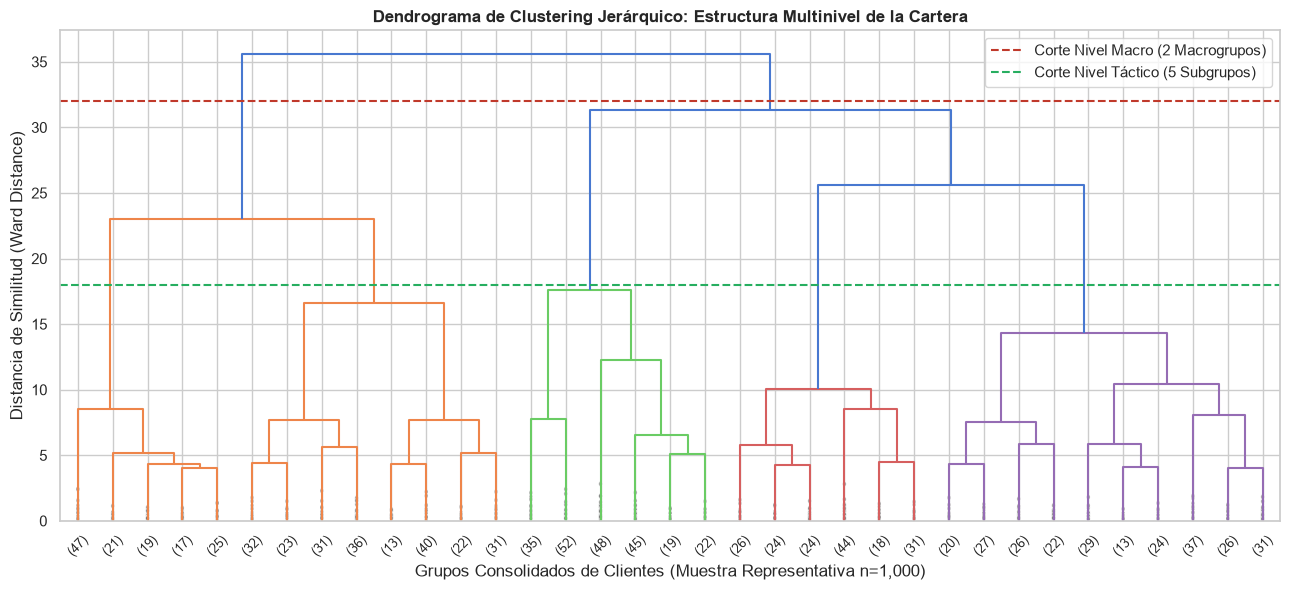

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Extracción de muestra representativa (n=1000) para viabilidad computacional
np.random.seed(42)
indices_muestra = np.random.choice(len(X_scaled), size=1000, replace=False)
X_muestra = X_scaled[indices_muestra]

# Cálculo de enlace jerárquico por método de Ward
enlace_ward = linkage(X_muestra, method='ward')

# Generación del Dendrograma Ejecutivo
plt.figure(figsize=(13, 6))
dendrogram(
    enlace_ward, truncate_mode='lastp', p=35, 
    leaf_rotation=45, leaf_font_size=9, show_contracted=True
)
plt.title('Dendrograma de Clustering Jerárquico: Estructura Multinivel de la Cartera', fontweight='bold')
plt.xlabel('Grupos Consolidados de Clientes (Muestra Representativa n=1,000)')
plt.ylabel('Distancia de Similitud (Ward Distance)')
plt.axhline(y=32, color='#c0392b', linestyle='--', label='Corte Nivel Macro (2 Macrogrupos)')
plt.axhline(y=18, color='#27ae60', linestyle='--', label='Corte Nivel Táctico (5 Subgrupos)')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Auditoría Cuantitativa y Validación de Calidad (*Silhouette Score*)

### Enfoque Gerencial
Al no existir etiquetas previas del cliente (*Ground Truth*), la dirección de analítica evalúa la calidad del agrupamiento mediante el **Coeficiente de Silueta (*Silhouette Score*)**:
$$s = \frac{b - a}{\max(a, b)}$$
Donde:
- $a$: Distancia media del cliente a los demás miembros de su propio cluster (cohesión interna).
- $b$: Distancia media del cliente al cluster vecino más cercano (separación externa).

Un coeficiente cercano a $+1$ denota segmentos hipercompactos y bien diferenciados, mientras que valores cercanos a $0$ indican fronteras comerciales compartidas.

In [9]:
from sklearn.metrics import silhouette_score

# Evaluación sobre muestra de auditoría para K-Means
sil_kmeans = silhouette_score(X_muestra, df.loc[indices_muestra, 'Cluster_KMeans'])

# Ajuste y evaluación de Clustering Jerárquico en la muestra
agg_model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
etiquetas_agg = agg_model.fit_predict(X_muestra)
sil_jerarquico = silhouette_score(X_muestra, etiquetas_agg)

# Auditoría comparativa
df_auditoria = pd.DataFrame({
    'Modelo Evaluado': ['K-Means (k=5)', 'Clustering Jerárquico (k=5)'],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_jerarquico, 4)],
    'Escalabilidad en Producción': ['Lineal O(N) - Apto para millones de clientes', 'Cuadrática O(N^2) - Apto para taxonomías y muestras'],
    'Aplicación de Negocio Recomendada': ['Segmentación automatizada en tiempo real', 'Planeación estratégica anual y portafolios']
})

print("=== CUADRO DE AUDITORÍA Y EVALUACIÓN ANALÍTICA ===")
display.display(df_auditoria)

=== CUADRO DE AUDITORÍA Y EVALUACIÓN ANALÍTICA ===


,Modelo Evaluado,Silhouette Score,Escalabilidad en Producción,Aplicación de Negocio Recomendada
0,K-Means (k=5),0.2693,Lineal O(N) - Apto para millones de clientes,Segmentación automatizada en tiempo real
1,Clustering Jerárquico (k=5),0.2281,Cuadrática O(N^2) - Apto para taxonomías y mue...,Planeación estratégica anual y portafolios


## 7. Formulación de la Estrategia Corporativa Basada en Segmentos

### Caracterización Ejecutiva de la Cartera
Calculamos las métricas centrales de cada segmento derivado del modelo de producción K-Means, bautizando cada arquetipo para su adopción por las áreas de negocio.

In [ ]:
# Resumen de negocio por segmento
resumen = df.groupby('Cluster_KMeans')[['Age', 'Annual Income', 'Spending Score']].mean().round(1)
resumen['Clientes'] = df['Cluster_KMeans'].value_counts()
resumen['Participacion_%'] = ((df['Cluster_KMeans'].value_counts() / len(df)) * 100).round(1)

# Bautizo estratégico de cada arquetipo según sus métricas empíricas
nombres_estrategicos = {
    0: 'Senior Patrimonial / Alto Valor (Edad Avanzada, Muy Alto Ingreso, Alto Gasto)',
    1: 'Profesionales Consolidados (Adultos Jóvenes, Muy Alto Ingreso, Gasto Moderado)',
    2: 'Jóvenes Cautelosos / Ahorro (Adultos Jóvenes, Ingreso Moderado, Bajo Gasto)',
    3: 'Consumidores Impulsivos (Edad Media, Ingreso Moderado, Muy Alto Gasto)',
    4: 'Tradicionales Conservadores (Adultos Mayores, Ingreso Medio-Alto, Bajo Gasto)'
}

resumen['Arquetipo_Estrategico'] = [nombres_estrategicos.get(i, f'Segmento {i}') for i in resumen.index]

print("=== MATRIZ EJECUTIVA DE SEGMENTACIÓN CORPORATIVA ===")
display(resumen[['Arquetipo_Estrategico', 'Clientes', 'Participacion_%', 'Annual Income', 'Spending Score', 'Age']])

=== MATRIZ EJECUTIVA DE SEGMENTACIÓN CORPORATIVA ===


,Arquetipo_Estrategico,Clientes,Participacion_%,Annual Income,Spending Score,Age
Cluster_KMeans,,,,,,
0,Senior Patrimonial / Alto Valor (Edad Avanzada...,2714,18.0,151668.1,72.6,71.7
1,"Profesionales Consolidados (Adultos Jóvenes, M...",3295,21.9,159418.1,49.6,35.0
2,"Jóvenes Cautelosos / Ahorro (Adultos Jóvenes, ...",2600,17.2,66538.3,27.5,37.3
3,"Consumidores Impulsivos (Edad Media, Ingreso M...",3246,21.5,62648.2,77.8,52.7
4,"Tradicionales Conservadores (Adultos Mayores, ...",3224,21.4,105939.0,24.3,74.3


### Plan de Acción y Hoja de Ruta para la Transformación Digital

| Arquetipo de Cliente | Perfil Operacional | Estrategia de Transformación Digital y Fidelización |
|---|---|---|
| **Senior Patrimonial / Alto Valor** | ~72 años, $151k ingreso, Score 73 | Experiencia digital simplificada y accesible, servicios de *concierge* omnicanal, eventos exclusivos de alta gama y atención preferente en canales físicos y digitales. |
| **Profesionales Consolidados** | ~35 años, $159k ingreso, Score 50 | Marketing de inversión, productos de suscripción premium (*lifestyle*), herramientas de gestión patrimonial y programas de fidelidad basados en beneficios de viaje. |
| **Consumidores Impulsivos** | ~53 años, $63k ingreso, Score 78 | Soluciones de financiamiento embebido (*Buy Now Pay Later - BNPL*), promociones dinámicas por notificaciones *push*, programas de recompensas inmediatas y venta cruzada (*cross-selling*). |
| **Jóvenes Cautelosos / Ahorro** | ~37 años, $66k ingreso, Score 27 | Cupones de descuento personalizados en la app móvil, paquetes de conveniencia, programas de acumulación de puntos por compras esenciales y precios competitivos. |
| **Tradicionales Conservadores** | ~74 años, $106k ingreso, Score 24 | Mensajes de valor enfocados en confiabilidad, durabilidad y tradición de marca; canales de autoservicio asistido y programas de fidelización con beneficios familiares. |

## 8. Casos de Éxito en la Industria y Lecciones para la Alta Dirección

1. **Retail Inteligente y E-Commerce (Amazon, Mercado Libre, Walmart):**  
   Utilizan modelos de agrupamiento para reconfigurar en tiempo real las páginas de inicio según el arquetipo de navegación y consumo del cliente, incrementando la tasa de conversión (*conversion rate*) entre un 12% y un 20%.

2. **Sector Bancario y FinTech (Detección de Fraude Transaccional):**  
   El uso de DBSCAN permite identificar transacciones atípicas y anomalías telemáticas que difieren de la masa densa de transferencias habituales, bloqueando fraudes en milisegundos sin requerir reglas manuales rígidas.

3. **Servicios de Streaming y Medios (Spotify, Netflix):**  
   El agrupamiento no supervisado organiza catálogos masivos y descubre micronichos de audiencia, permitiendo recomendaciones personalizadas que maximizan la tasa de retención y reducen la fuga de clientes (*churn*).